In [224]:
import hashlib
import os

# UOV Implementation

In [225]:
class UOV:
    def __init__(self, q, n, o):

        self.n = n      # number of variables
        self.o = o      # number of oil variales
        self.v = n - o  # number of vinegar variables
        self.q = q      # size of the finite field
        self.m = o      # number of polynomials

        print(f"uov = UOV(q={q}, n={n} , o={o})\n")

        # keys
        self.private_key = None
        self.public_key = None

        # fintite field F_q
        self.F = GF(q)
        
        # polynomial ring: F_q[x_0, x_1, ..., x_{n-1}]
        self.R = PolynomialRing(self.F, [f'x{i}' for i in range(n)])
        self.vars = self.R.gens()
        
        # indices of oil and vinegar variables
        self.vinegar_indices = list(range(self.v))
        self.oil_indices = list(range(self.v, self.n))



    def generate_private_key(self, seed=None):

        if seed is not None:
            set_random_seed(seed)

        print("Generating private key...")

        P_secret = []

        for k in range(self.m):
            polynomial = self.R(0)

            # constant term
            polynomial += self.F.random_element()

            # linear vinegar and oil terms
            for i in range(self.n):
                polynomial += self.F.random_element() * self.vars[i]           

            # quadratic vinegar * vinegar terms
            for i in self.vinegar_indices:
                for j in self.vinegar_indices:
                    if j >= i:
                        polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

            # quadratic oil * vinegar terms
            for i in self.oil_indices:
                for j in self.vinegar_indices:
                    polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

            P_secret.append(polynomial)

        # create the matrix representation of a random affine map T
        # P = P_secret ° T
        T = random_matrix(self.F, self.n, self.n)
        while not T.is_invertible():
            T = random_matrix(self.F, self.n, self.n)

        # translation part of the affine map T
        t = vector([self.F.random_element() for _ in range(self.n)])

        self.private_key = {
            'P_secret': P_secret,
            'T': T,
            't': t
        }

        print("Private key generated\n")
        return self.private_key



    def generate_public_key(self):

        if self.private_key is None:
            raise ValueError("Generate the private key first with generate_private_key()")

        print("Generating public key...")

        P_secret = self.private_key['P_secret']
        T = self.private_key['T']
        t = self.private_key['t']

        P = []
        subs_dict = {}

        # computes the new variables y_i = T(x_i)
        for i in range(self.n):
            expr = t[i]
            for j in range(self.n):
                expr += T[i, j] * self.vars[j]
            subs_dict[self.vars[i]] = expr

        # substitute the obtained variables in P_secret
        for idx, P_secret_polynomial in enumerate(P_secret):
            P_polynomial = P_secret_polynomial.subs(subs_dict)
            P.append(P_polynomial)

        self.public_key = P

        print("Pulic key generated\n")
        return self.public_key



    def sign(self, message, max_attempts=100):

        if self.private_key is None:
            raise ValueError("Generate the private key first with generate_private_key()")

        print("Signing message...")

        salt = os.urandom(16)
        msg = self._hash_message(message, salt)
        
        P_secret = self.private_key['P_secret']
        T = self.private_key['T']
        t = self.private_key['t']
    
        for attempt in range(max_attempts):
            # create constant random vinegar values
            v_values = [self.F.random_element() for _ in range(self.v)]

            # build the linear system to be solved, by replacing the vinegar varibales by the new constants
            mat, constant_vector = self._build_linear_system(P_secret, v_values)
            if not mat.is_invertible():
                print(f"Attempt {attempt+1}: the system doesn't have solution, new attempt")
                continue
        
            # solve the system: mat * oils = msg - constant
            constant_vector = vector(self.F, constant_vector)
            msg_vector = vector(self.F, msg)
            right_side = msg_vector - constant_vector
            o_values = mat.solve_right(right_side)

            # put back all the oil and vinegar solutions values together 
            solution_values = []
            for v_idx in self.vinegar_indices:
                solution_values.append(v_values[self.vinegar_indices.index(v_idx)])
            for oil_idx in self.oil_indices:
                solution_values.append(o_values[self.oil_indices.index(oil_idx)])
            
            solution_vector = vector(self.F, solution_values)
            
            # signature = T⁻¹ * (solution_vector - t)
            signature_vector = T.inverse() * (solution_vector - t)

            print("Message signed")
            return signature_vector, salt

    
        print(f"Failed after {max_attempts} attemps")
        return None, salt



    def verify(self, siganture_vec, salt, message):

        P = self.public_key
        msg_test = []

        subs_dict = {}
        for idx in range(self.n):
            subs_dict[self.vars[idx]] = siganture_vec[idx]
 
        # substitute oil and vinegars variables with the values of the signature
        for idx, public_polynomial in enumerate(P):
            new_polynomial = public_polynomial.subs(subs_dict)
            msg_test.append(self.F(new_polynomial))

        return msg_test == self._hash_message(message, salt)



    # maybe not the best
    def _hash_message(self, message, salt):

        shake = hashlib.shake_256()
        shake.update(message.encode())
        shake.update(salt)
        hash_bytes = shake.digest(self.o)

        result = []
        for i in range(self.o):
            result.append(self.F(hash_bytes[i] % self.q))

        return result



    def _build_linear_system(self, P_secret, v_values):

        mat = []
        constant_vector = []
        
        for secret_polynomial in P_secret:
            subs_dict = {}
            for idx in self.vinegar_indices:
                subs_dict[self.vars[idx]] = v_values[self.vinegar_indices.index(idx)]

            new_polynomial = secret_polynomial.subs(subs_dict)

            # put oil variables' coefficients on a matrix
            row = []
            for oil_idx in self.oil_indices:
                coeff = new_polynomial.coefficient(self.vars[oil_idx])
                row.append(coeff)
            mat.append(row)
            
            # constant terms (when oil_value = 0)
            const = new_polynomial.subs({self.vars[idx]: 0 for idx in self.oil_indices})
            constant_vector.append(const)
        
        return Matrix(self.F, mat), vector(self.F, constant_vector)



    def display_infos(self):
        print(f"uov = UOV(q={self.q}, n={self.n} , o={self.o})\n")        


In [226]:
class UOV_Ip(UOV):
    def __init__(self):
        q = 256
        n = 112
        o = 44
        super().__init__(q, n, o)

class UOV_Is(UOV):
   def __init__(self):
        q = 16
        n = 160
        o = 64
        super().__init__(q, n, o)

class UOV_III(UOV):
    def __init__(self):
        q = 256
        n = 184
        o = 72
        super().__init__(q, n, o)

class UOV_V(UOV):
    def __init__(self):
        q = 256
        n = 244
        o = 96
        super().__init__(q, n, o)

## UOV Test

In [227]:
def get_uov(version="", q=256, n=20, o=4):
    if version == 'Ip':
        print("SL-Ip version:")
        return UOV_Ip()
    elif version == 'Is':
        print("SL-Is version")
        return UOV_Is()
    elif version == 'III':
        print("SL-III version")
        return UOV_III()
    elif version == 'V':
        print("SL-V version")
        return UOV_V()
    else:
        print("Unknow version:")
        return UOV(q, n, o)

def generate_keypair(uov):
    private_key = uov.generate_private_key(seed=None)
    public_key = uov.generate_public_key()

    return private_key, public_key

def sign_message(uov, message):
    signature_vector, salt = uov.sign(message)
    return signature_vector, salt

def verify_signature(uov, signature, salt, message):
    verif_worked = uov.verify(signature, salt, message)
    print(f"\nVerification worked: {verif_worked}")

def test_all_functions(uov, message):
    print("\n\n============================")
    print("Testing all functions with:")
    uov.display_infos()
    private_key, public_key = generate_keypair(uov)
    signature, salt = sign_message(uov, message)
    verify_signature(uov, signature, salt, message)

In [228]:
uov = get_uov(q=256, n=30, o=6)
uov_Ip = get_uov("Ip")
uov_Is = get_uov("Is")
uov_III = get_uov("III")
uov_V = get_uov("V")

test_all_functions(uov, "Test")
#test_all_functions(uov_Ip, "Test")
#test_all_functions(uov_Is, "Test")
#test_all_functions(uov_III, "Test")
#test_all_functions(uov_V, "Test")

Unknow version:
uov = UOV(q=256, n=30 , o=6)

SL-Ip version:
uov = UOV(q=256, n=112 , o=44)

SL-Is version
uov = UOV(q=16, n=160 , o=64)

SL-III version
uov = UOV(q=256, n=184 , o=72)

SL-V version
uov = UOV(q=256, n=244 , o=96)



Testing all functions with:
uov = UOV(q=256, n=30 , o=6)

Generating private key...
Private key generated

Generating public key...
Pulic key generated

Signing message...
Message signed

Verification worked: True


# RAINBOW Implementation

In [229]:
class RAINBOW:

    def __init__(self, q, layers):

        self.q = q                  # size of the finite field
        self.layers = layers        # list of number of variables for each layer
        self.n = sum(layers)        # numer of variables
        self.l = len(layers)-1      # number of oil layers
        self.m = self.n - layers[0] # number of polynomials
        self.indices = []           # list of indixes for each layer
        self.V = []                 # list of indices for each V_l layer
        self.O = []                 # list of indices for each O_l layer

        # keys
        self.private_key = None
        self.public_key = None

        # fintite field F_q
        self.F = GF(q)
        
        # polynomial ring: F_q[x_0, x_1, ..., x_{n-1}]
        self.R = PolynomialRing(self.F, [f'x{i}' for i in range(self.n)])
        self.vars = self.R.gens()

        # create indices with self.layers
        first_elt = 0
        last_elt = 0
        for i in range(len(self.layers)):
            last_elt += layers[i]
            self.indices.append(list(range(first_elt, last_elt)))
            first_elt = last_elt

        # add indices lists in V and O
        self.V.append(self.indices[0])
        for l in range(self.l):
            self.O.append(self.indices[l + 1])
            
            # V_(l+1) = Vl U Ol (if it is not the last layer)
            if l < self.l - 1:
                next_V = []
                for v in self.V[l]:
                    next_V.append(v)
                for o in self.O[l]:
                    next_V.append(o)
                self.V.append(next_V)

        print(f"uov = UOV(q={self.q}, layers={self.layers})\n") 



    def generate_private_key(self, seed=None):

        print("Generating private key...")

        if seed is not None:
            set_random_seed(seed)

        F = []
        vinegar_indices = []
        oil_indices = []

        # create polynomials for each layer
        for l in range(self.l):
            Vl = self.V[l]
            Ol = self.O[l]

            # we have the same number of polynomials that oil variables for each layer
            for k in range(len(Ol)):
                polynomial = self.R(0)
    
                # constant term
                polynomial += self.F.random_element()

                # linear vinegar and oil terms
                for i in Vl:
                    polynomial += self.F.random_element() * self.vars[i]
                for i in Ol:
                    polynomial += self.F.random_element() * self.vars[i]          
    
                # quadratic vinegar * vinegar terms
                for i in Vl:
                    for j in Vl:
                        if j >= i:
                            polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

                # quadratic vinegar * oil terms
                for i in Ol:
                    for j in Vl:
                        polynomial += self.F.random_element() * self.vars[i] * self.vars[j]
    
                F.append(polynomial)

        # create the matrix representation of two random affine maps S and T
        # P = S ° F ° T => S(F(T + t)) + s
        S = random_matrix(self.F, self.m, self.m)
        while not S.is_invertible():
            S = random_matrix(self.F, self.m, self.m)

        T = random_matrix(self.F, self.n, self.n)
        while not T.is_invertible():
            T = random_matrix(self.F, self.n, self.n)

        # the translation part of S and T
        s = vector([self.F.random_element() for _ in range(self.m)])
        t = vector([self.F.random_element() for _ in range(self.n)])
    
        self.private_key = {
            'F': F,
            'S': S,
            's': s, # a in the paper
            'T': T,
            't': t  # b in the paper
        }

        print("Private key generated\n")
        return self.private_key



    def generate_public_key(self):

        if self.private_key is None:
            raise ValueError("Generate the private key first with generate_private_key()")

        print("Generating public key...")

        F = self.private_key['F']
        S = self.private_key['S']
        s = self.private_key['s']
        T = self.private_key['T']
        t = self.private_key['t']

        subs_dict = {}

        # apply T to the variables
        for i in range(self.n):
            expr = t[i]
            for j in range(self.n):
                expr += T[i, j] * self.vars[j]
            subs_dict[self.vars[i]] = expr

        F_T = []
        # substitute the obtained variables in F to obtain F_T = F(T(x))
        for idx, F_polynomial in enumerate(F):
            F_T_polynomial = F_polynomial.subs(subs_dict)
            F_T.append(F_T_polynomial)
    
        P = []  
        # obtain P = S(F(T(x))) = S(F_T)
        for i in range(self.m):
            polynomial = s[i]
            for j in range(self.m):
                polynomial += S[i, j] * F_T[j]
            P.append(polynomial)
    
        self.public_key = P

        print("Public key generated\n")
        return self.public_key

    

    def sign(self, message, max_attempts=1000):

        if self.private_key is None:
            raise ValueError("Generate the private key first with generate_private_key()")

        print("Signing message...")

        salt = os.urandom(16)
        hashed_message = self._hash_message(message, salt)

        F = self.private_key['F']
        S = self.private_key['S']
        s = self.private_key['s']
        T = self.private_key['T']
        t = self.private_key['t']

        # get F(x) = S⁻¹(hashed_message - s)
        hashed_message_vec = vector(self.F, hashed_message)
        target_F = S.inverse() * (hashed_message_vec - s)

        for attempt in range(max_attempts):
            # create constant random vinegar values
            v_values = {}
            for i in self.V[0]:
                v_values[i] = self.F.random_element()
    
            success = True
            v_l = 0

            # we find solutions for each layer and add the found values on the vinegar part of the next layer
            for l in range(self.l):
                Vl = self.V[l]
                Ol = self.O[l]
                ol = len(Ol)

                F_layer = F[v_l : v_l + ol]
                v_l += ol

                start = sum(len(self.O[i]) for i in range(l))
                target_layer = target_F[start : start + ol]

                # build the linear system to be solved, by replacing the vinegar varibales by the new constants
                mat, constant_vector = self._build_linear_system_layer(F_layer, Vl, Ol, v_values)
                solution_vector = vector(self.F, target_layer)
    
                if not mat.is_invertible():
                    success = False
                    break

                
                # solve the system: mat * oils = msg - constant
                oil_values = mat.solve_right(solution_vector - constant_vector)

                for i, oil_idx in enumerate(Ol):
                    v_values[oil_idx] = oil_values[i]
    
            if not success:
                continue

            # put back all the oil and vinegar solutions values together 
            solution_vector = vector(self.F, [v_values[i] for i in range(self.n)])

            # signature = T⁻¹ * (solution_vector - t)
            signature_vector = T.inverse() * (solution_vector - t)

            print("Message signed")            
            return signature_vector, salt
    
        print(f"Failed after {max_attempts} attempts")
        return None, None


    def verify(self, siganture_vec, salt, message):

        P = self.public_key
        msg_test = []

        subs_dict = {}
        for idx in range(self.n):
            subs_dict[self.vars[idx]] = siganture_vec[idx]
 
        # substitute oil and vinegars variables with the values of the signature
        for idx, public_polynomial in enumerate(P):
            new_polynomial = public_polynomial.subs(subs_dict)
            msg_test.append(self.F(new_polynomial))

        return msg_test == self._hash_message(message, salt)



    def _build_linear_system_layer(self, F_layer, vinegar_indices, oil_indices, v_values):

        mat = []
        constant_vector = []
        
        for polynomial in F_layer:
            subs_dict = {}
            for i in vinegar_indices:
                subs_dict[self.vars[i]] = v_values[i]
            polynomial_subs = polynomial.subs(subs_dict)

            row = []
            for oil_idx in oil_indices:
                coeff = polynomial_subs.coefficient(self.vars[oil_idx])
                row.append(coeff)
            mat.append(row)

            const = self.F(polynomial_subs.subs({self.vars[oil_idx]: 0 for oil_idx in oil_indices}))
            constant_vector.append(const)
        
        return Matrix(self.F, mat), vector(self.F, constant_vector)



    def _hash_message(self, message, salt):

        shake = hashlib.shake_256()
        shake.update(message.encode())
        shake.update(salt)
        hash_bytes = shake.digest(self.m)

        result = []
        for i in range(self.m):
            result.append(self.F(hash_bytes[i] % self.q))

        return result



    def display_infos(self):
        print(f"uov = UOV(q={self.q}, layers={self.layers})\n") 

In [230]:
class RAINBOW_I(RAINBOW):
    def __init__(self):
        q = 16
        v1 = 36
        o1 = 32
        o2 = 32
        super().__init__(q, [v1, o1, o2])

class RAINBOW_III(RAINBOW):
     def __init__(self):
        q = 256
        v1 = 68
        o1 = 32
        o2 = 48
        super().__init__(q, [v1, o1, o2])

class RAINBOW_V(RAINBOW):
    def __init__(self):
        q = 256
        v1 = 96
        o1 = 36
        o2 = 64
        super().__init__(q, [v1, o1, o2])

## RAINBOW Test

In [231]:
def get_rainbow(version="", q=256, layers=[5, 5, 5]):
    if version == 'I':
        print("SL-I version:")
        return RAINBOW_I()
    elif version == 'III':
        print("SL-III version")
        return RAINBOW_III()
    elif version == 'V':
        print("SL-V version")
        return RAINBOW_V()
    else:
        print("Unknow version:")
        return RAINBOW(q, layers)

def generate_keypair(rainbow):
    private_key = rainbow.generate_private_key(seed=None)
    public_key = rainbow.generate_public_key()

    return private_key, public_key

def sign_message(rainbow, message):
    signature_vector, salt = rainbow.sign(message)
    return signature_vector, salt

def verify_signature(rainbow, signature, salt, message):
    verif_worked = rainbow.verify(signature, salt, message)
    print(f"\nVerification worked: {verif_worked}")

def test_all_functions(rainbow, message):
    print("\n\n============================")
    print("Testing all functions with:")
    rainbow.display_infos()
    private_key, public_key = generate_keypair(rainbow)
    signature, salt = sign_message(rainbow, message)
    verify_signature(rainbow, signature, salt, message)

In [232]:
rainbow = get_rainbow(q=256, layers=[5, 5, 5])
rainbow_I = get_rainbow("I")
rainbow_III = get_rainbow("III")
rainbow_V = get_rainbow("V")

test_all_functions(rainbow, "Test")
#test_all_functions(uov_Ip, "Test")
#test_all_functions(uov_Is, "Test")
#test_all_functions(uov_III, "Test")
#test_all_functions(uov_V, "Test")

Unknow version:
uov = UOV(q=256, layers=[5, 5, 5])

SL-I version:
uov = UOV(q=16, layers=[36, 32, 32])

SL-III version
uov = UOV(q=256, layers=[68, 32, 48])

SL-V version
uov = UOV(q=256, layers=[96, 36, 64])



Testing all functions with:
uov = UOV(q=256, layers=[5, 5, 5])

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed

Verification worked: True


# VDOO Implementation

In [233]:
class VDOO:

    def __init__(self, q, v, d, o1, o2):

        self.q = q    # size of the finite field
        self.d = d    # diagonal layer polynomials
        self.v = v    # first vinegar layer size
        self.o1 = o1  # oil1 layer size
        self.o2 = o2  # oil2 layer size
        self.indices = []
        self.V = []
        self.O = []
        self.layers = [v, d, o1, o2]
        self.n = sum(self.layers)
        self.l = len(self.layers) - 1
        self.m = self.n - self.layers[0]

        # keys
        self.private_key = None
        self.public_key = None

        # finite field F_q
        self.F = GF(q)
        
        # polynomial ring: F_q[x_0, x_1, ..., x_{n-1}]
        self.R = PolynomialRing(self.F, [f'x{i}' for i in range(self.n)])
        self.vars = self.R.gens()

        # create indices with self.layers (comme RAINBOW)
        first_elt = 0
        last_elt = 0
        for i in range(len(self.layers)):
            last_elt += self.layers[i]
            self.indices.append(list(range(first_elt, last_elt)))
            first_elt = last_elt

        # add indices lists in V and O (comme RAINBOW)
        self.V.append(self.indices[0])  # V0 = vinegar indices
        for l in range(self.l):
            self.O.append(self.indices[l + 1])  # O_l = indices of layer l+1
            
            # V_(l+1) = V_l U O_l (if it is not the last layer)
            if l < self.l - 1:
                next_V = []
                for v in self.V[l]:
                    next_V.append(v)
                for o in self.O[l]:
                    next_V.append(o)
                self.V.append(next_V)

        print(f"uov = UOV(q={self.q}, v={self.v}, d={self.d}, o1={self.o1}, o2={self.o2})\n") 



    def generate_private_key(self, seed=None):

        print("Generating private key...")

        if seed is not None:
            set_random_seed(seed)

        F = []
        # create polynomials for each layer (d, oil1, oil2)
        for l in range(len(self.O)):
            Vl = self.V[l]
            Ol = self.O[l]
            
            for k in Ol:
                polynomial = self.R(0)

                # diagonal layer
                if l == 0:
                    for i in range(k):
                        polynomial += self.F.random_element() * self.vars[i] * self.vars[k]

                    for i in range(k):
                        for j in range(k):
                            polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

                else:
                    # quadratic vinegar * vinegar terms
                    for i in Vl:
                        for j in Vl:
                            polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

                    # quadratic vinegar * oil terms
                    for i in Vl:
                        for j in Ol:
                            polynomial += self.F.random_element() * self.vars[i] * self.vars[j]

                    
                
                F.append(polynomial)
        
        # create the matrix representation of two random affine maps S and T
        # P = S ° F ° T => S(F(T + t)) + s
        S = random_matrix(self.F, self.m, self.m)
        while not S.is_invertible():
            S = random_matrix(self.F, self.m, self.m)
        
        T = random_matrix(self.F, self.n, self.n)
        while not T.is_invertible():
            T = random_matrix(self.F, self.n, self.n)
        
        # the translation part of S and T
        s = vector([self.F.random_element() for _ in range(self.m)])
        t = vector([self.F.random_element() for _ in range(self.n)])
        
        self.private_key = {
            'F': F,
            'S': S,
            's': s,
            'T': T,
            't': t
        }
        
        print("Private key generated\n")
        return self.private_key



    def generate_public_key(self):
        
        if self.private_key is None:
            raise ValueError("Generate the private key first with generate_private_key()")
        
        print("Generating public key...")
        
        F = self.private_key['F']
        S = self.private_key['S']
        s = self.private_key['s']
        T = self.private_key['T']
        t = self.private_key['t']
        
        # apply T to the variables
        subs_dict = {}
        for i in range(self.n):
            expr = t[i]
            for j in range(self.n):
                expr += T[i, j] * self.vars[j]
            subs_dict[self.vars[i]] = expr
        
        F_T = []
        # substitute the obtained variables in F to obtain F_T = F(T(x))
        for idx, F_polynomial in enumerate(F):
            F_T_polynomial = F_polynomial.subs(subs_dict)
            F_T.append(F_T_polynomial)

        P = []
        # obtain P = S(F(T(x))) = S(F_T)
        for i in range(self.m):
            polynomial = s[i]
            for j in range(self.m):
                polynomial += S[i, j] * F_T[j]
            P.append(polynomial)
        
        self.public_key = P

        print("Public key generated\n")
        return self.public_key


    
    def sign(self, message, max_attempts=1000):
    
        if self.private_key is None:
            raise ValueError("Generate private key first")
        
        print("Signing message...")

        salt = os.urandom(16)
        hashed_message = self._hash_message(salt, message)

        F = self.private_key['F']
        S = self.private_key['S']
        s = self.private_key['s']
        T = self.private_key['T']
        t = self.private_key['t']
        
        # Compute target: S⁻¹(y - s)
        hashed_message_vec = vector(self.F, hashed_message)
        target_F = S.inverse() * (hashed_message_vec - s)


        # solve the linear system (thanks to random constant vinegar variables)
        for attempt in range(max_attempts):
            # create random constant vinegar variables
            v_values = {}
            for idx in self.V[0]:
                v_values[idx] = self.F.random_element()
            
            polynomial_idx = 0
            success = True
            
            # we find solutions for each layer (d, oil1, oil2)
            for l in range(self.l):
                Vl = self.V[l]
                Ol = self.O[l]
                
                if l == 0:
                    v_values, polynomial_idx, success = self._solve_diagonal_layer(
                        F, v_values, polynomial_idx, target_F, Vl, Ol
                    )
                else:
                    v_values, polynomial_idx, success = self._solve_oil_layer(
                        F, v_values, polynomial_idx, target_F, l, Vl, Ol
                    )

                if not success:
                    break
            
            if not success:
                continue
            

            # put back all the solutions values together
            solution_vector = vector(self.F, [v_values[i] for i in range(self.n)])

            # signature = T⁻¹ * (solution_vector - t)
            signature = T.inverse() * (solution_vector - t)
            
            print("Message signed")
            return signature, salt
        
        print(f"Failed to sign after {max_attempts} attempts")
        return None, salt



    def verify(self, siganture_vec, salt, message):

        P = self.public_key
        msg_test = []

        subs_dict = {}
        for idx in range(self.n):
            subs_dict[self.vars[idx]] = siganture_vec[idx]
 
        # substitute oil and vinegars variables with the values of the signature
        for idx, public_polynomial in enumerate(P):
            new_polynomial = public_polynomial.subs(subs_dict)
            msg_test.append(self.F(new_polynomial))

        return msg_test == self._hash_message(salt, message)



    def _solve_diagonal_layer(self, F, v_values, polynomial_idx, target_F, Vl, Ol):

        for k in Ol:
            polynomial = F[polynomial_idx]
            polynomial_idx += 1

            subs_dict = {}
            for i in v_values:
                subs_dict[self.vars[i]] = v_values[i]
            polynomial_subs = polynomial.subs(subs_dict)

            coeff = polynomial_subs.coefficient(self.vars[k])
            const = self.F(polynomial_subs.subs({self.vars[k]: 0}))

            target_val = target_F[polynomial_idx - 1]

            # if coeff == 0, 0.x_k + cst = target_val, x_k can be a random value, if cst = target_val
            if coeff == 0:
                if const != target_val:
                    return v_values, polynomial_idx, False
    
                v_values[k] = self.F.random_element()
            else:
                v_values[k] = (target_val - const) / coeff
        
        return v_values, polynomial_idx, True



    def _solve_oil_layer(self, F, v_values, polynomial_idx, target_F, layer_idx, Vl, Ol):

        ol = len(Ol)
        F_layer = F[polynomial_idx:polynomial_idx + ol]
        polynomial_idx += ol

        if layer_idx == 1:  # oil1 layer
            start_idx = self.d
        else:  # oil2 layer
            start_idx = self.d + self.o1
        
        target_layer = target_F[start_idx:start_idx + ol]

        # build the linear system to be solved, by replacing the vinegar varibales by the new constants
        mat, const_vec = self._build_linear_system(F_layer, Vl, Ol, v_values)
            
        if not mat.is_invertible():
            return v_values, polynomial_idx, False

        # solve the system: mat * oils = target_layer - const_vec
        oil_values = mat.solve_right(vector(self.F, target_layer) - const_vec)
          
        for i, oil_idx in enumerate(Ol):
            v_values[oil_idx] = oil_values[i]

        
        return v_values, polynomial_idx, True



    def _build_linear_system(self, F_layer, vinegar_indices, oil_indices, current_values):

        mat = []
        const_vec = []
        
        for polynomial in F_layer:
            subs_dict = {}
            for i in vinegar_indices:
                subs_dict[self.vars[i]] = current_values[i]
            polynomial_subs = polynomial.subs(subs_dict)

            # put oil variables' coefficients on a matrix
            row = []
            for oil_idx in oil_indices:
                coeff = polynomial_subs.coefficient(self.vars[oil_idx])
                row.append(coeff)
            mat.append(row)
            
            # constant terms (when oil_value = 0)
            const = self.F(polynomial_subs.subs({self.vars[idx]: 0 for idx in oil_indices}))
            const_vec.append(const)
        
        return Matrix(self.F, mat), vector(self.F, const_vec)

    

    def _hash_message(self, salt, message):

        shake = hashlib.shake_256()
        shake.update(message.encode())
        shake.update(salt)
        hash_bytes = shake.digest(self.m)

        result = []
        for i in range(self.m):
            result.append(self.F(hash_bytes[i] % self.q))

        return result



    def display_infos(self):
        print(f"uov = UOV(q={self.q}, v={self.v}, d={self.d}, o1={self.o1}, o2={self.o2})\n") 

In [234]:
class VDOO_I(VDOO):
    def __init__(self):
        q = 16
        v = 60
        d = 30
        o1 = 34
        o2 = 36
        super().__init__(q, v, d, o1, o2)

class VDOO_III(VDOO):
     def __init__(self):
        q = 16
        v = 100
        d = 30
        o1 = 40
        o2 = 40
        super().__init__(q, v, d, o1, o2)

class VDOO_V(VDOO):
    def __init__(self):
        q = 16
        v = 120
        d = 50
        o1 = 60
        o2 = 70
        super().__init__(q, v, d, o1, o2)

## VDOO Test

In [235]:
def get_vdoo(version="", q=256, v=5, d=5, o1=5, o2=5):
    if version == 'I:':
        print("SL-Is version")
        return VDOO_Is()
    elif version == 'III':
        print("SL-III version")
        return VDOO_III()
    elif version == 'V':
        print("SL-V version")
        return VDOO_V()
    else:
        print("Unknow version:")
        return VDOO(q, v, d, o1, o2)

def generate_keypair(vdoo):
    private_key = vdoo.generate_private_key(seed=None)
    public_key = vdoo.generate_public_key()

    return private_key, public_key

def sign_message(vdoo, message):
    signature_vector, salt = vdoo.sign(message)
    return signature_vector, salt

def verify_signature(vdoo, signature, salt, message):
    verif_worked = vdoo.verify(signature, salt, message)
    print(f"\nVerification worked: {verif_worked}")

def test_all_functions(vdoo, message):
    print("\n\n============================")
    print("Testing all functions with:")
    vdoo.display_infos()
    private_key, public_key = generate_keypair(vdoo)
    signature, salt = sign_message(vdoo, message)
    verify_signature(vdoo, signature, salt, message)

In [236]:
vdoo = get_vdoo(q=256, v=5, d=5, o1=5, o2=5)
vdoo_Ip = get_vdoo("Ip")
vdoo_Is = get_vdoo("Is")
vdoo_III = get_vdoo("III")
vdoo_V = get_vdoo("V")

test_all_functions(vdoo, "Test")
#test_all_functions(uov_Ip, "Test")
#test_all_functions(uov_Is, "Test")
#test_all_functions(uov_III, "Test")
#test_all_functions(uov_V, "Test")

Unknow version:
uov = UOV(q=256, v=5, d=5, o1=5, o2=5)

Unknow version:
uov = UOV(q=256, v=5, d=5, o1=5, o2=5)

Unknow version:
uov = UOV(q=256, v=5, d=5, o1=5, o2=5)

SL-III version
uov = UOV(q=16, v=100, d=30, o1=40, o2=40)

SL-V version
uov = UOV(q=16, v=120, d=50, o1=60, o2=70)



Testing all functions with:
uov = UOV(q=256, v=5, d=5, o1=5, o2=5)

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed

Verification worked: True


# Benchmark

In [237]:
import time
import pickle
import matplotlib.pyplot as plt

def sizeof(obj):
    return len(pickle.dumps(obj)) / 1024

is_list = list(range(1, 13))

rainbow_times = {"private": [], "public": [], "sign": [], "verify": []}
vdoo_times    = {"private": [], "public": [], "sign": [], "verify": []}
uov_times     = {"private": [], "public": [], "sign": [], "verify": []}

rainbow_sizes = {"private": [], "public": [], "signature": []}
vdoo_sizes    = {"private": [], "public": [], "signature": []}
uov_sizes     = {"private": [], "public": [], "signature": []}

def benchmark():
    for i in is_list:
        print(f"\n\n\nStep {i}\n")

        rainbow = RAINBOW(151, [i, i, i, i])
        
        t0 = time.time()
        private_key = rainbow.generate_private_key()
        t1 = time.time()
        public_key = rainbow.generate_public_key()
        t2 = time.time()
        signature, salt = rainbow.sign("test")
        t3 = time.time()
        verif = rainbow.verify(signature, salt, "test")
        t4 = time.time()

        rainbow_times["private"].append(t1-t0)
        rainbow_times["public"].append(t2-t1)
        rainbow_times["sign"].append(t3-t2)
        rainbow_times["verify"].append(t4-t3)

        rainbow_sizes["private"].append(sizeof(private_key))
        rainbow_sizes["public"].append(sizeof(public_key))
        rainbow_sizes["signature"].append(sizeof(signature))


        
        vdoo = VDOO(151, i, i, i, i)
        
        t0 = time.time()
        private_key = vdoo.generate_private_key()
        t1 = time.time()
        public_key = vdoo.generate_public_key()
        t2 = time.time()
        signature, salt = vdoo.sign("test")
        t3 = time.time()
        verif = vdoo.verify(signature, salt, "test")
        t4 = time.time()

        vdoo_times["private"].append(t1-t0)
        vdoo_times["public"].append(t2-t1)
        vdoo_times["sign"].append(t3-t2)
        vdoo_times["verify"].append(t4-t3)

        vdoo_sizes["private"].append(sizeof(private_key))
        vdoo_sizes["public"].append(sizeof(public_key))
        vdoo_sizes["signature"].append(sizeof(signature))


        
        uov = UOV(151, 4*i, i)

        t0 = time.time()
        private_key = uov.generate_private_key()
        t1 = time.time()
        public_key = uov.generate_public_key()
        t2 = time.time()
        signature, salt = uov.sign("test")
        t3 = time.time()
        verif = uov.verify(signature, salt, "test")
        t4 = time.time()

        uov_times["private"].append(t1-t0)
        uov_times["public"].append(t2-t1)
        uov_times["sign"].append(t3-t2)
        uov_times["verify"].append(t4-t3)

        uov_sizes["private"].append(sizeof(private_key))
        uov_sizes["public"].append(sizeof(public_key))
        uov_sizes["signature"].append(sizeof(signature))

benchmark()




Step 1

uov = UOV(q=151, layers=[1, 1, 1, 1])

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed
uov = UOV(q=151, v=1, d=1, o1=1, o2=1)

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed
uov = UOV(q=151, n=4 , o=1)

Generating private key...
Private key generated

Generating public key...
Pulic key generated

Signing message...
Message signed



Step 2

uov = UOV(q=151, layers=[2, 2, 2, 2])

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed
uov = UOV(q=151, v=2, d=2, o1=2, o2=2)

Generating private key...
Private key generated

Generating public key...
Public key generated

Signing message...
Message signed
uov = UOV(q=151, n=8 , o=2)

Generating private key...
Private key generated

Generating public key...
Pulic key generated

Signing message...



Test for i in [1, k] of UOV(151, 4*i), RAINBOW(151, i, i, i, i) and VDOO(151, i, i, i, i)


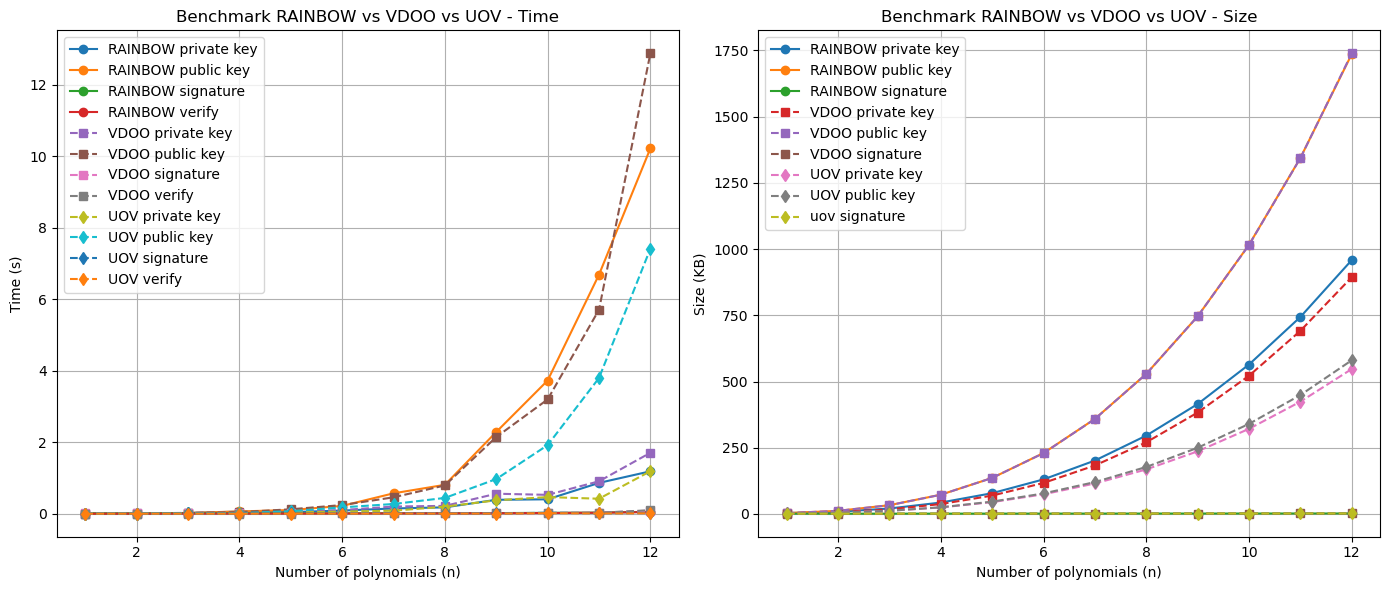

In [192]:
print("\n\nTest for i in [1, k] of UOV(151, 4*i), RAINBOW(151, i, i, i, i) and VDOO(151, i, i, i, i)")
plt.figure(figsize=(14,6))

# Generation / signature / verification Time
plt.subplot(1,2,1)
is_list = [is_list[i] for i in range(len(is_list))]
plt.plot(is_list, rainbow_times["private"], 'o-', label="RAINBOW private key")
plt.plot(is_list, rainbow_times["public"], 'o-', label="RAINBOW public key")
plt.plot(is_list, rainbow_times["sign"], 'o-', label="RAINBOW signature")
plt.plot(is_list, rainbow_times["verify"], 'o-', label="RAINBOW verify")

plt.plot(is_list, vdoo_times["private"], 's--', label="VDOO private key")
plt.plot(is_list, vdoo_times["public"], 's--', label="VDOO public key")
plt.plot(is_list, vdoo_times["sign"], 's--', label="VDOO signature")
plt.plot(is_list, vdoo_times["verify"], 's--', label="VDOO verify")

plt.plot(is_list, uov_times["private"], 'd--', label="UOV private key")
plt.plot(is_list, uov_times["public"], 'd--', label="UOV public key")
plt.plot(is_list, uov_times["sign"], 'd--', label="UOV signature")
plt.plot(is_list, uov_times["verify"], 'd--', label="UOV verify")

plt.xlabel("Number of polynomials (n)")
plt.ylabel("Time (s)")
plt.title("Benchmark RAINBOW vs VDOO vs UOV - Time")
plt.legend()
plt.grid(True)

# Keys/signature sizes
plt.subplot(1,2,2)
plt.plot(is_list, rainbow_sizes["private"], 'o-', label="RAINBOW private key")
plt.plot(is_list, rainbow_sizes["public"], 'o-', label="RAINBOW public key")
plt.plot(is_list, rainbow_sizes["signature"], 'o-', label="RAINBOW signature")

plt.plot(is_list, vdoo_sizes["private"], 's--', label="VDOO private key")
plt.plot(is_list, vdoo_sizes["public"], 's--', label="VDOO public key")
plt.plot(is_list, vdoo_sizes["signature"], 's--', label="VDOO signature")

plt.plot(is_list, uov_sizes["private"], 'd--', label="UOV private key")
plt.plot(is_list, uov_sizes["public"], 'd--', label="UOV public key")
plt.plot(is_list, uov_sizes["signature"], 'd--', label="uov signature")

plt.xlabel("Number of polynomials (n)")
plt.ylabel("Size (KB)")
plt.title("Benchmark RAINBOW vs VDOO vs UOV - Size")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()